In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum12"

## Import Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

##Load Data

In [5]:
df = pd.read_csv(path + '/data/data.csv', sep=",")

df = df.drop(['id', 'Unnamed: 32'], axis=1)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
df.head()

Shape X: (569, 30)
Shape y: (569,)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


##Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data train:", X_train.shape)
print("Data test:", X_test.shape)

Data train: (455, 30)
Data test: (114, 30)


##Standarisasi Data

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Penerapan Model SVM Tanpa PCA

In [9]:
svm_no_pca = SVC(kernel='rbf', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi SVM tanpa PCA:", acc_no_pca)

Akurasi SVM tanpa PCA: 0.9736842105263158


##Penerapan PCA

In [10]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

##Variansi yang Dijelaskan oleh Setiap Komponen PCA

In [11]:
explained_variance = pca.explained_variance_ratio_

for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

PC1: 0.4459
PC2: 0.1855
PC3: 0.0958
PC4: 0.0659
PC5: 0.0562
PC6: 0.0399
PC7: 0.0221
PC8: 0.0161
PC9: 0.0128
PC10: 0.0117
PC11: 0.0101
PC12: 0.0091
PC13: 0.0079
PC14: 0.0048
PC15: 0.0030
PC16: 0.0025
PC17: 0.0020
PC18: 0.0017
PC19: 0.0016
PC20: 0.0011
PC21: 0.0010
PC22: 0.0008
PC23: 0.0008
PC24: 0.0005
PC25: 0.0005
PC26: 0.0003
PC27: 0.0002
PC28: 0.0001
PC29: 0.0000
PC30: 0.0000


##Membangun Model SVM dengan PCA (3 Komponen)

In [12]:
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)

svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(X_train_pca3, y_train)

y_pred_pca = svm_pca.predict(X_test_pca3)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Akurasi SVM dengan PCA:", acc_pca)

Akurasi SVM dengan PCA: 0.956140350877193


##Visualisasi PCA dalam Ruang 3 Dimensi

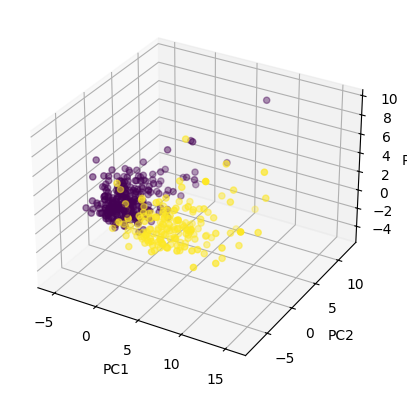

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca3[:, 0],
    X_train_pca3[:, 1],
    X_train_pca3[:, 2],
    c=y_train
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

##Perbandingan Model SVM Tanpa PCA dan Dengan PCA

In [14]:
comparison = pd.DataFrame({
    "Model": ["SVM tanpa PCA", "SVM dengan PCA"],
    "Akurasi": [acc_no_pca, acc_pca]
})

comparison

,Model,Akurasi
0,SVM tanpa PCA,0.973684
1,SVM dengan PCA,0.956140
